# DNN HW 1


## Handle imports & installs

In [1]:
# !wget https://github.com/marcin119a/data/raw/refs/heads/main/data_gsn.zip
# !unzip data_gsn.zip &> /dev/null
# !rm data_gsn.zip




In [2]:
import torch 
torch.manual_seed(0)

## Prepare the Torch dataframe

In [3]:
from dnn_solver.dataset import IMGDataset


dataset = IMGDataset(train=None)
dataset

Preloaded data shape: torch.Size([10000, 1, 28, 28])


Dataset IMGDataset
    Number of datapoints: 10000
    Root location: ./data

Verify that the images were loaded correctly:

index=1, targets: 
squares: 0 circles: 0 up: 0 right: 5 down: 0 left: 5 


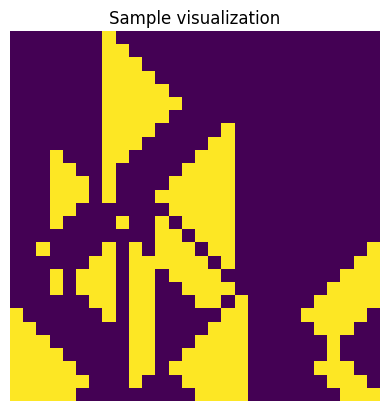

In [4]:
dataset.repr_item(1)

## Data Analysis

We focus on the labels df, verify the distribution of classes etc. 


In [5]:
labels_df = dataset.get_labels()

In [6]:
labels_df.describe()

,squares,circles,up,right,down,left
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.65740,1.714900,1.653000,1.677000,1.685700,1.612000
std,2.62909,2.656073,2.619557,2.627539,2.641101,2.574979
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000
max,8.00000,8.000000,8.000000,8.000000,8.000000,8.000000


In [7]:
# assert 1 not in df 
for col in labels_df.columns:
    assert 1 not in labels_df[col].values

It seems the max value for each col is 8, therefore there can be at most 6 * 5 / 2 * 7 = 105 classes represented, not 135 as described in the assignment. This is important because reducing the number of classes 1. reduces loss 2. will not lead to an unexpected behaviour when evaluating on a different dataset that has 1-9 splits. Therefore, we will proceed with the assumption that there should be 105 classes and not 135.

In [8]:
# TODO: use the utils
from dnn_solver.constants import TARGET_COL_NAMES


def get_configuration(row: dict) -> int: 
    #get names of columns that are not 0 
    selected_names = list(filter(lambda x: row[x] > 0, TARGET_COL_NAMES))
    # assert there are two of them 
    assert len(selected_names) == 2, f"Expected 2 non-zero columns, got {row}, selected_names={selected_names}"
    # get their indices 
    indices = list(map(lambda x: TARGET_COL_NAMES.index(x), selected_names))
    # sort the indices 
    indices.sort()
    # calculate the idx 
    idx = 0
    indices = sorted(TARGET_COL_NAMES.index(name) for name in selected_names)
    a, b = indices  # 0 <= a < b < n
    n = len(TARGET_COL_NAMES)
    pair_index = a * (2 * n - a - 1) // 2 + (b - a - 1)  # in [0, 14] for n=6
    idx += pair_index * 7
    idx += row[TARGET_COL_NAMES[indices[0]]] - 2
    return idx 

# Unit test for get_configuration
def make_row(i, j, v):
    """
    Build a row dict with exactly two non-zero columns:
    - column i has count v (2..9)
    - column j has count 2
    """
    row = {name: 0 for name in TARGET_COL_NAMES}
    row[TARGET_COL_NAMES[i]] = v
    row[TARGET_COL_NAMES[j]] = 10 - v
    return row

def test_get_configuration_105_unique_classes():
    seen = set()
    count = 0

    for i in range(len(TARGET_COL_NAMES)):
        for j in range(i + 1, len(TARGET_COL_NAMES)):
            for v in range(2, 9):  # 2..8 (7 values)
                count += 1
                row = make_row(i, j, v)
                cfg = get_configuration(row)

                # config index should live in [0, 120)
                assert 0 <= cfg < 105
                seen.add(cfg)

    # 6 choose 2 = 15 pairs, 15 * 7 = 105
    assert len(seen) == 105, f"Expected 105 unique configurations, got {len(seen)}"
    assert count == 105

test_get_configuration_105_unique_classes()
labels_df['configuration'] = labels_df.apply(get_configuration, axis=1)


array([[<Axes: title={'center': 'configuration'}>]], dtype=object)

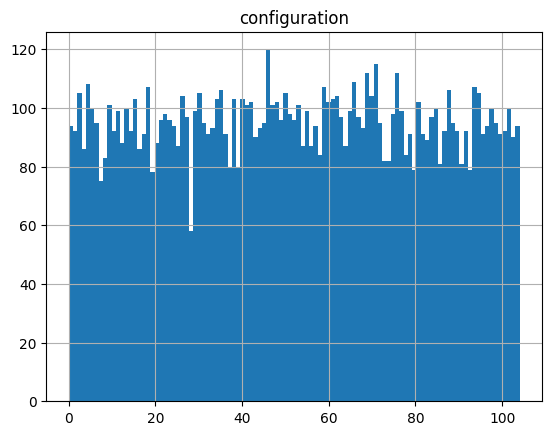

In [9]:
labels_df[['configuration']].hist(bins=105)

In [10]:
config_dist = labels_df["configuration"].value_counts().sort_index()
config_dist.describe()

count    105.000000
mean      95.238095
std        9.364955
min       58.000000
25%       91.000000
50%       95.000000
75%      102.000000
max      120.000000
Name: count, dtype: float64

All of the classes seem to be pretty well represented (except maybe for one, but it still doesn't seem like an issue). Here we've checked for the entire dataset, assuming the train/test split required by the assignment definition was done randomly, the same should hold for the train/test datasets. 

The plotted embeddings are not included in the notebook as they don't really tell any info.
    

## Model setup

In [11]:
import torch

torch.manual_seed(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [12]:
from dnn_solver import DataAugmentation
from torch.utils.data import DataLoader

from dnn_solver.types import DataAugmentationConfig, FlipAugmentationConfig, GaussianNoiseAugmentationConfig, RotationAugmentationConfig


config = DataAugmentationConfig(
    flip=FlipAugmentationConfig(probability=0.2, horizontal=True, vertical=True),
    rotation=RotationAugmentationConfig(probability=0.2),
    gaussian_noise=GaussianNoiseAugmentationConfig(probability=0.1, mean=0.0, std=0.05),
)

train_dataset = IMGDataset(train=True, transform=DataAugmentation(config))
val_dataset   = IMGDataset(train=False)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=1000, shuffle=False)


Preloaded data shape: torch.Size([9000, 1, 28, 28])
Preloaded data shape: torch.Size([1000, 1, 28, 28])


In [15]:
from dnn_solver.net import GSNMultiTaskNet
from dnn_solver.trainer import MultiTaskTrainer


def run_experiment(lambda_cnt: float, use_cls_loss: bool, *, epochs: int = 100, weight_decay: float = 1e-4, log_freq: int = 50, patience: int = 15, save_dir: str | None = None):
    use_cls_loss = use_cls_loss
    model = GSNMultiTaskNet(num_classes=135, dropout_p=0.3).to(device)
    trainer = MultiTaskTrainer(
        model=model,
        trainloader=train_loader,
        testloader=val_loader,
        device=device,
        lambda_cnt=lambda_cnt,
        use_cls_loss=use_cls_loss,
    )
    metrics = trainer.train(
        epochs=epochs,
        lr=1e-3,
        weight_decay=weight_decay,
        log_freq=log_freq,
        patience=patience,
    )
    trainer.plot_learning_curves(save_dir=save_dir)
    return metrics


epoch    1, batch    50, loss 4.786
epoch    1, batch   100, loss 4.700
epoch    1 evaluation: loss_total=4.6740, accuracy=0.0090
               loss_cls=4.6740, loss_reg=1.5000
epoch    2, batch    50, loss 4.682
epoch    2, batch   100, loss 4.676
epoch    2 evaluation: loss_total=4.6664, accuracy=0.0070
               loss_cls=4.6664, loss_reg=1.5000
epoch    3, batch    50, loss 4.668
epoch    3, batch   100, loss 4.668
epoch    3 evaluation: loss_total=4.6629, accuracy=0.0110
               loss_cls=4.6629, loss_reg=1.5000
epoch    4, batch    50, loss 4.663
epoch    4, batch   100, loss 4.593
epoch    4 evaluation: loss_total=4.1457, accuracy=0.0240
               loss_cls=4.1457, loss_reg=1.5000
epoch    5, batch    50, loss 4.097
epoch    5, batch   100, loss 4.004
epoch    5 evaluation: loss_total=3.9006, accuracy=0.0390
               loss_cls=3.9006, loss_reg=1.5000
epoch    6, batch    50, loss 3.888
epoch    6, batch   100, loss 3.848
epoch    6 evaluation: loss_total=3.68

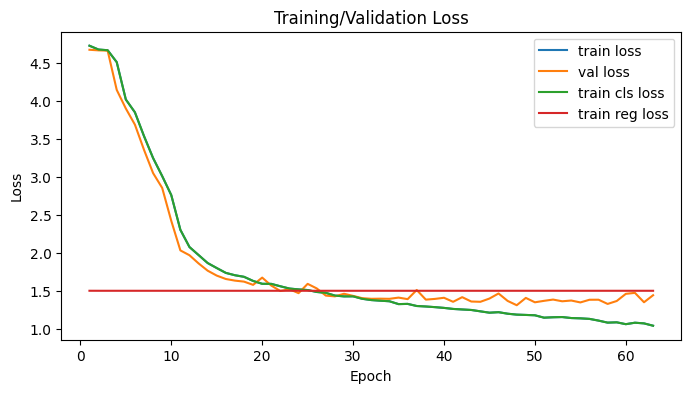

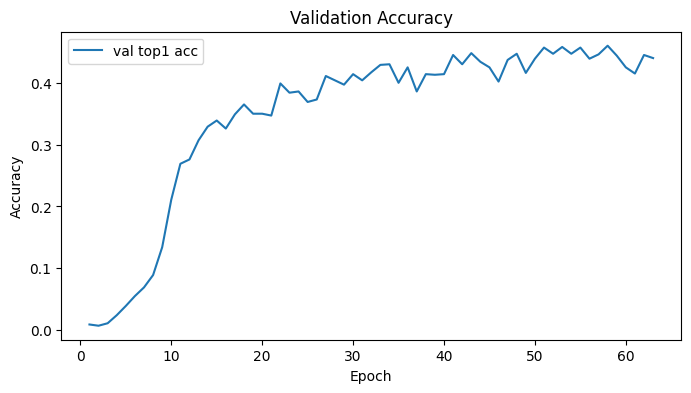

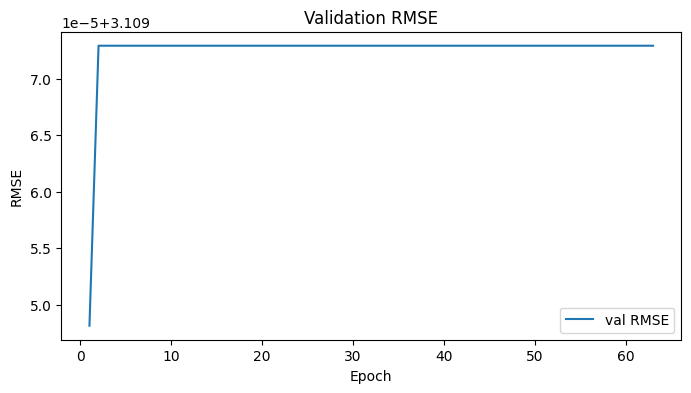

[Loss] loss_total=1.3097, loss_cls=1.3097, loss_reg=1.5000; [Classification] top1=0.4470, macro_f1=0.4167, worst_pairs={'squares+left': 0.8551, 'circles+left': 0.875, 'right+down': 0.9032, 'squares+circles': 0.9048, 'up+right': 0.9231}; [Regression] rmse_overall=3.1091, mae_overall=1.6667, rmse_per_dim={'squares': 3.0966, 'circles': 3.0976, 'up': 3.1672, 'right': 3.1826, 'down': 3.0674, 'left': 3.0406}, mae_per_dim={'squares': 1.651, 'circles': 1.659, 'up': 1.719, 'right': 1.701, 'down': 1.631, 'left': 1.639}

In [16]:
run_experiment(lambda_cnt=0, use_cls_loss=True)

epoch    1, batch    50, loss 1.427
epoch    1, batch   100, loss 1.411
epoch    1 evaluation: loss_total=1.2959, accuracy=0.0130
               loss_cls=0.0000, loss_reg=1.2959
epoch    2, batch    50, loss 1.227
epoch    2, batch   100, loss 1.082
epoch    2 evaluation: loss_total=0.9024, accuracy=0.0060
               loss_cls=0.0000, loss_reg=0.9024
epoch    3, batch    50, loss 0.842
epoch    3, batch   100, loss 0.680
epoch    3 evaluation: loss_total=0.5304, accuracy=0.0050
               loss_cls=0.0000, loss_reg=0.5304
epoch    4, batch    50, loss 0.547
epoch    4, batch   100, loss 0.485
epoch    4 evaluation: loss_total=0.3699, accuracy=0.0080
               loss_cls=0.0000, loss_reg=0.3699
epoch    5, batch    50, loss 0.399
epoch    5, batch   100, loss 0.370
epoch    5 evaluation: loss_total=0.3212, accuracy=0.0100
               loss_cls=0.0000, loss_reg=0.3212
epoch    6, batch    50, loss 0.333
epoch    6, batch   100, loss 0.338
epoch    6 evaluation: loss_total=0.27

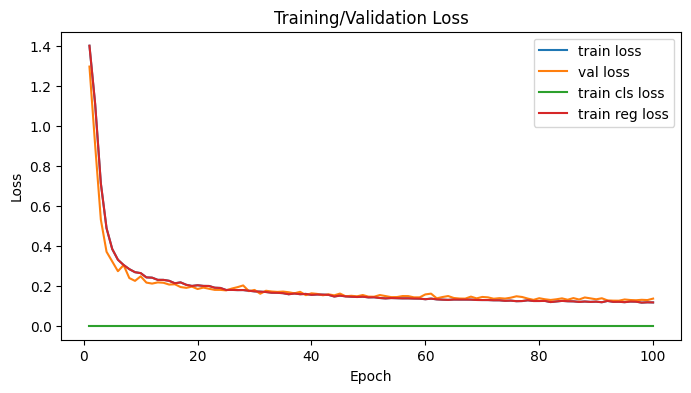

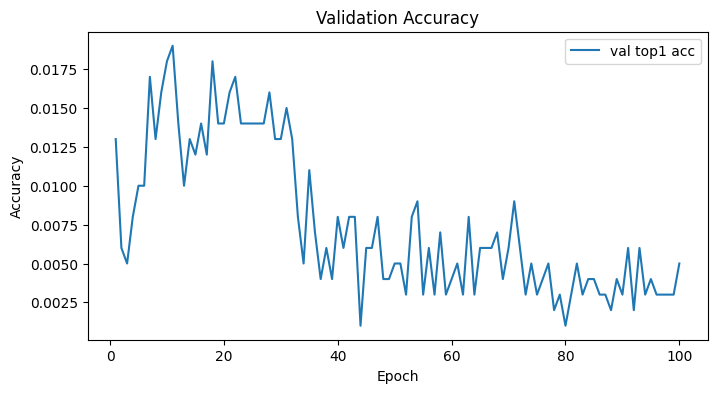

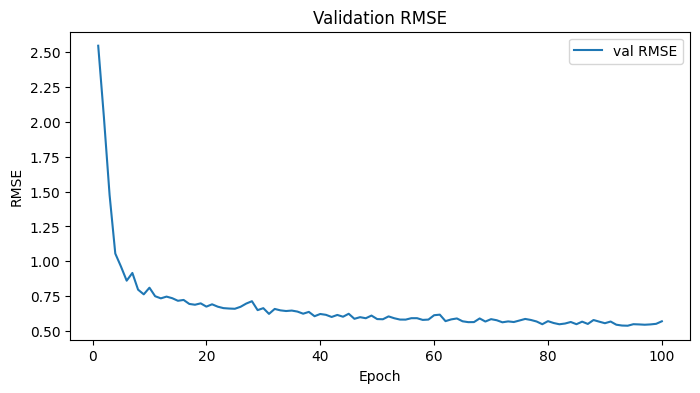

[Loss] loss_total=0.1252, loss_cls=0.0000, loss_reg=0.1252; [Classification] top1=0.0030, macro_f1=0.0027, worst_pairs={'squares+circles': 0.0, 'squares+up': 0.0, 'squares+right': 0.0, 'squares+left': 0.0, 'circles+up': 0.0}; [Regression] rmse_overall=0.5388, mae_overall=0.2968, rmse_per_dim={'squares': 0.4829, 'circles': 0.5174, 'up': 0.5621, 'right': 0.5452, 'down': 0.5447, 'left': 0.5752}, mae_per_dim={'squares': 0.2552, 'circles': 0.304, 'up': 0.3196, 'right': 0.2883, 'down': 0.2964, 'left': 0.3172}

In [17]:
run_experiment(lambda_cnt=1.0, use_cls_loss=False)

epoch    1, batch    50, loss 6.221
epoch    1, batch   100, loss 6.124
epoch    1 evaluation: loss_total=6.0951, accuracy=0.0070
               loss_cls=4.6785, loss_reg=1.4166
epoch    2, batch    50, loss 6.099
epoch    2, batch   100, loss 5.909
epoch    2 evaluation: loss_total=5.1961, accuracy=0.0530
               loss_cls=3.9488, loss_reg=1.2473
epoch    3, batch    50, loss 4.911
epoch    3, batch   100, loss 4.522
epoch    3 evaluation: loss_total=3.9713, accuracy=0.1190
               loss_cls=3.0286, loss_reg=0.9427
epoch    4, batch    50, loss 4.035
epoch    4, batch   100, loss 3.771
epoch    4 evaluation: loss_total=3.2169, accuracy=0.1500
               loss_cls=2.5431, loss_reg=0.6738
epoch    5, batch    50, loss 3.261
epoch    5, batch   100, loss 2.983
epoch    5 evaluation: loss_total=2.6700, accuracy=0.2300
               loss_cls=2.2013, loss_reg=0.4687
epoch    6, batch    50, loss 2.645
epoch    6, batch   100, loss 2.585
epoch    6 evaluation: loss_total=2.36

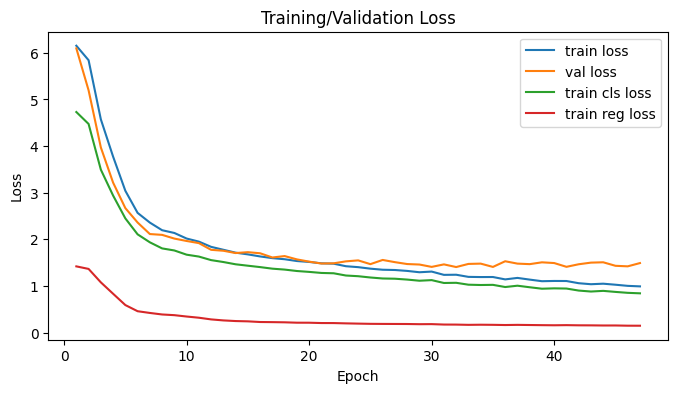

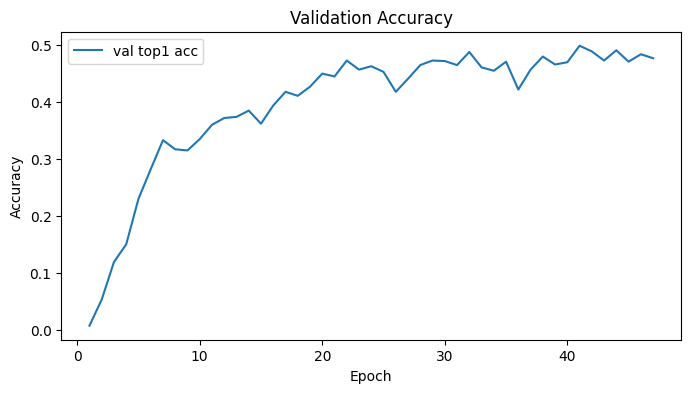

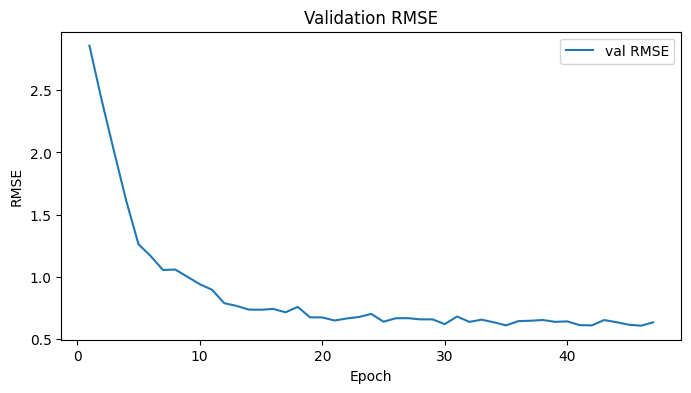

[Loss] loss_total=1.4068, loss_cls=1.2401, loss_reg=0.1667; [Classification] top1=0.4880, macro_f1=0.4433, worst_pairs={'squares+up': 0.8857, 'squares+right': 0.8889, 'up+right': 0.9077, 'squares+left': 0.9275, 'circles+down': 0.9344}; [Regression] rmse_overall=0.6358, mae_overall=0.3523, rmse_per_dim={'squares': 0.5494, 'circles': 0.5369, 'up': 0.7059, 'right': 0.6558, 'down': 0.6415, 'left': 0.7039}, mae_per_dim={'squares': 0.3157, 'circles': 0.3045, 'up': 0.3876, 'right': 0.3671, 'down': 0.3554, 'left': 0.3832}

In [18]:
run_experiment(lambda_cnt=1.0, use_cls_loss=True)